# Push fleet model — demo & smoke test

Runs Paco's delivery-driven (**"push"**) fleet engine as a selectable AeroMAPS
efficiency model (`models_efficiency_push`) over the TP/RJ/NB/WB passenger
segments (`markets_push.yaml`).

**The push engine is calibrated to the end-2024 fleet**, so a scenario using it
**must pivot on 2024** (`prospection_start_year = 2025`). This demo uses the
ad-hoc 2000–2024 historic vectors from
`tutorials/13_change_the_prospection_start_year` (`inputs_2025.json`), wired via
`data/config_push_2025.yaml`, and runs to `end_year = 2070`.

Per-segment demand growth follows the **legacy push profile**, now expressed as
the markets' `inputs.growth.cagr_reference_periods` (ported from the engine's old
`default_market_param.yaml::reference_growth`), so the injected ASK matches the
trajectory the fleet was calibrated against.

Scope: the drop-in efficiency bridge (energy-per-ASK + 100 % drop-in shares)
**plus** the push model's distinguishing fleet state — per-segment & per-type
**fleet counts** and **deliveries** — surfaced as AeroMAPS outputs, and the
model's own `plot()` method for the diagnostic charts.

> **Note.** The engine still raises `ValueError` if delivered capacity can't meet
> demand in any year (legacy fail-loud behaviour) — this calibrated scenario just
> doesn't trip it anymore.

In [9]:
import warnings
import matplotlib.pyplot as plt
from aeromaps import create_process

warnings.simplefilter("ignore")  # quiet the reference-year notices + push feasibility logs

# CWD is the notebook dir; the config's paths are relative to itself.
process = create_process(configuration_file="data/config_push_2025.yaml")
process.compute()

print("prospection_start_year :", process.parameters.prospection_start_year)
print("last_historical_year   :", process.parameters.last_historical_year, "(engine pivot = 2024)")

prospection_start_year : 2025
last_historical_year   : 2024 (engine pivot = 2024)


## Per-segment energy-per-ASK

History (≤ 2024) is spliced from the AeroMAPS `energy_consumption_init / ask_init`
× the segment's 2024 energy/RPK shares; the projection (≥ 2025) is produced
bottom-up by the push engine from the surviving + delivered fleet. The 2024→2025
seam is smooth because both sides are now anchored on 2024.

In [10]:
segments = ["turboprop", "regional_jet", "narrow_body", "wide_body"]
df = process.data["vector_outputs"]

print(f"{'segment':14s}{'2024':>10s}{'2025':>10s}{'2050':>10s}   (MJ/ASK)")
for mid in segments:
    s = df[f"energy_per_ask_without_operations_{mid}_dropin_fuel"]
    print(f"{mid:14s}{s.loc[2024]:10.4f}{s.loc[2025]:10.4f}{s.loc[2050]:10.4f}")

segment             2024      2025      2050   (MJ/ASK)
turboprop         1.9244    1.8012    0.8984
regional_jet      2.3348    2.1919    1.3422
narrow_body       1.1459    1.0563    0.6685
wide_body         1.1935    1.1250    0.8092


## Fleet counts & deliveries (the push model's distinguishing state)

The push engine drives the fleet from aircraft **deliveries** and lets
retirement + utilisation curves determine the surviving fleet. Phase 5 surfaces
that native state as AeroMAPS outputs, mirroring `SimpleFleetCount`'s naming:

- `"<Segment>: Aircraft In Fleet"` — per-segment total fleet count.
- `<mid>:<aircraft_type>:aircraft_in_fleet` — per-type fleet count.
- `<mid>:<aircraft_type>:aircraft_deliveries` — per-type new deliveries per year.

**Year alignment.** Fleet counts are indexed at `last_historical_year + t`
(t = 0 is the 2024 pivot, carrying the calibrated end-2024 fleet snapshot);
deliveries at `first_projection_year + k` (2025 + k). Pre-pivot history
(2000–2023) is left NaN — the engine has no fleet state there.

In [12]:
segment_names = {
    "turboprop": "Turboprop",
    "regional_jet": "Regional Jet",
    "narrow_body": "Narrow Body",
    "wide_body": "Wide Body",
}

# Sanity table: per-segment fleet count & total deliveries at 2025 / 2035 / 2050.
hdr = f"{'segment':14s}" + "".join(f"{y:>14s}" for y in ("count25", "count35", "count50"))
hdr += "".join(f"{y:>12s}" for y in ("deliv25", "deliv35", "deliv50"))
print(hdr)
for mid, name in segment_names.items():
    total = df[f"{name}: Aircraft In Fleet"]
    deliv_cols = [
        c for c in df.columns if c.startswith(f"{mid}:") and c.endswith(":aircraft_deliveries")
    ]
    deliv = df[deliv_cols].sum(axis=1)
    row = f"{mid:14s}"
    row += "".join(f"{total.loc[y]:14.1f}" for y in (2025, 2035, 2050))
    row += "".join(f"{deliv.loc[y]:12.1f}" for y in (2025, 2035, 2050))
    print(row)

segment              count25       count35       count50     deliv25     deliv35     deliv50
turboprop             3215.8        2011.0        2052.0        20.0       181.0       100.8
regional_jet          3446.9        3185.7        3068.5        60.0        92.3        67.2
narrow_body          18131.9       20143.1       24762.6       650.0      1874.9      1270.2
wide_body             4598.6        4770.8        5828.7       110.0       201.9       435.6


### Diagnostic plots (the model's own `plot()` method)

All push charts are rendered by `PassengerAircraftEfficiencyFleetPush.plot()`,
mirroring `FleetModel.plot()`. `compute()` caches the engine's per-segment
**age-resolved** arrays (`self._engine_results`), and `plot()` draws, per segment:
the fleet / ASK / deliveries / energy stacks, the **retirement** and
**retirement-age** diagnostics (which need those internal `(periods, age, type)`
arrays, so they can't be `SingleScenarioPlot` registry plots), and the
energy-intensity curve. The matplotlib helpers live in
`fleet_model_push_visualisations.py`.

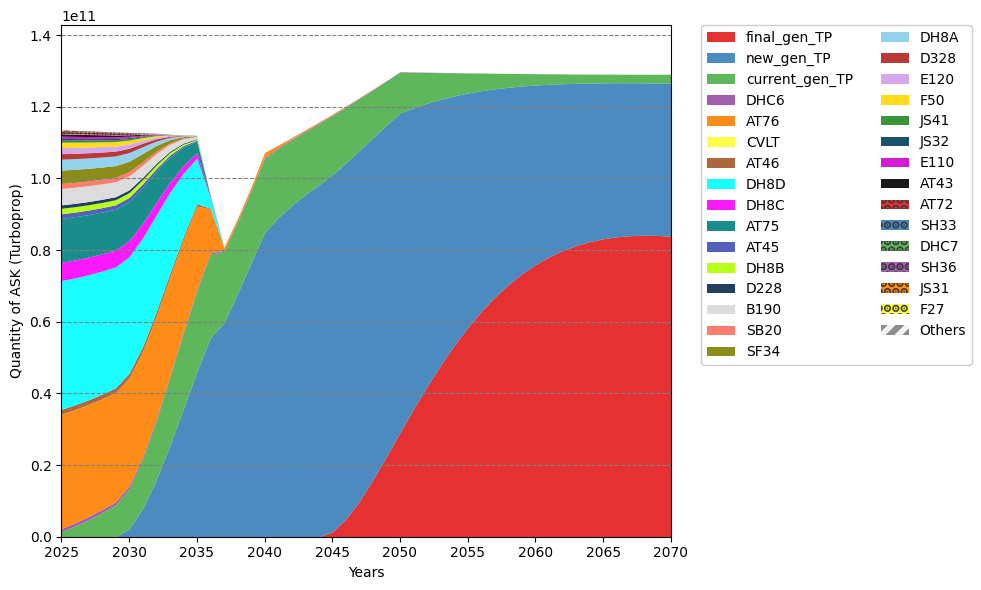

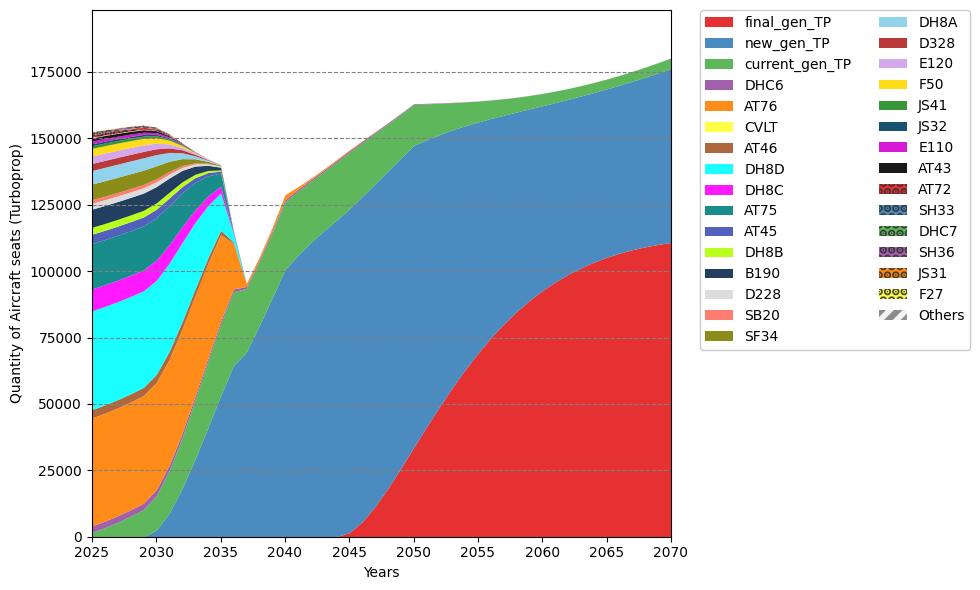

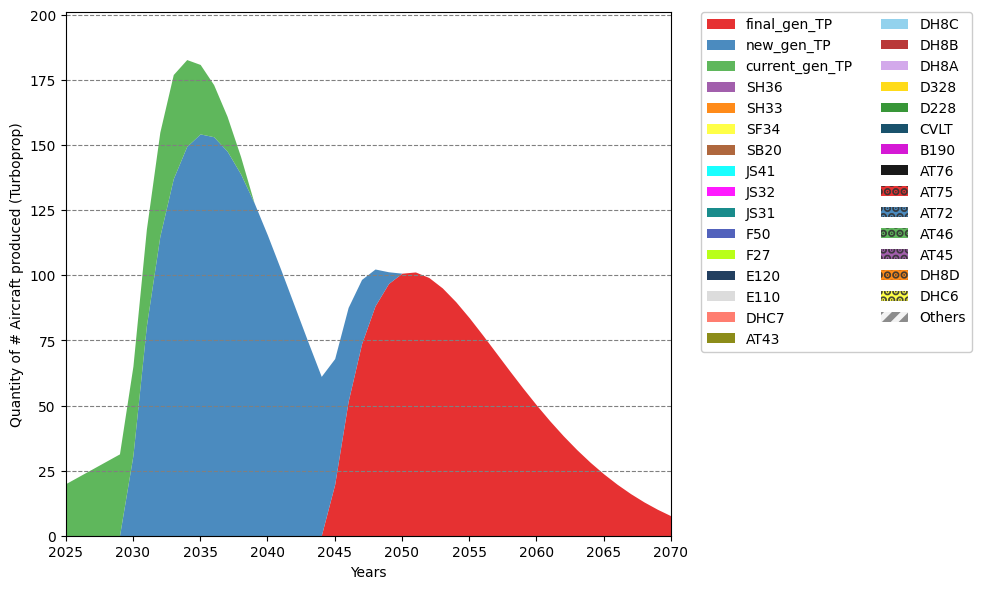

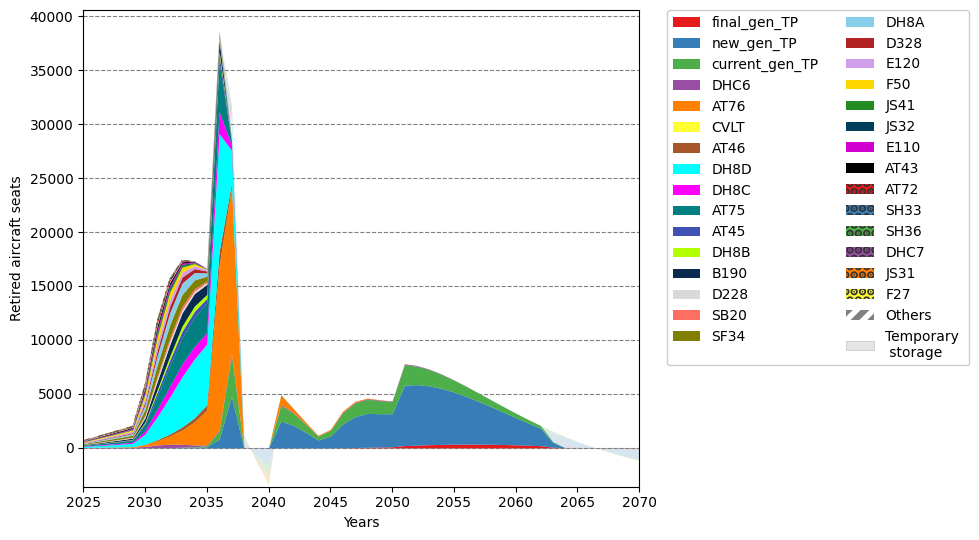

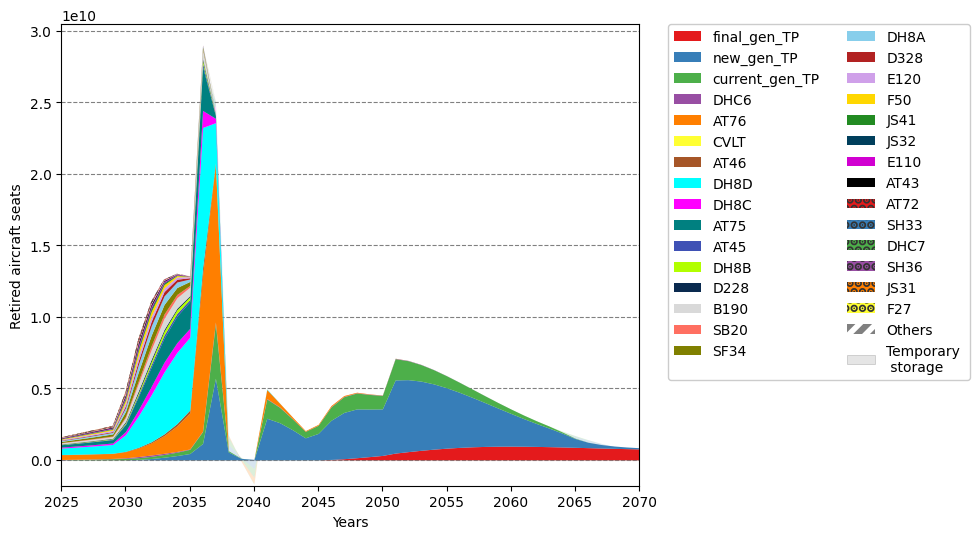

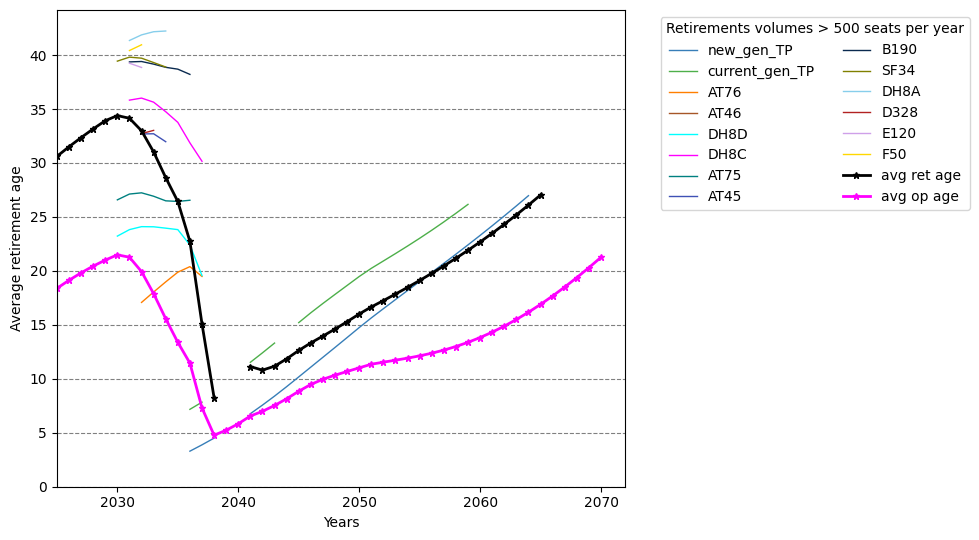

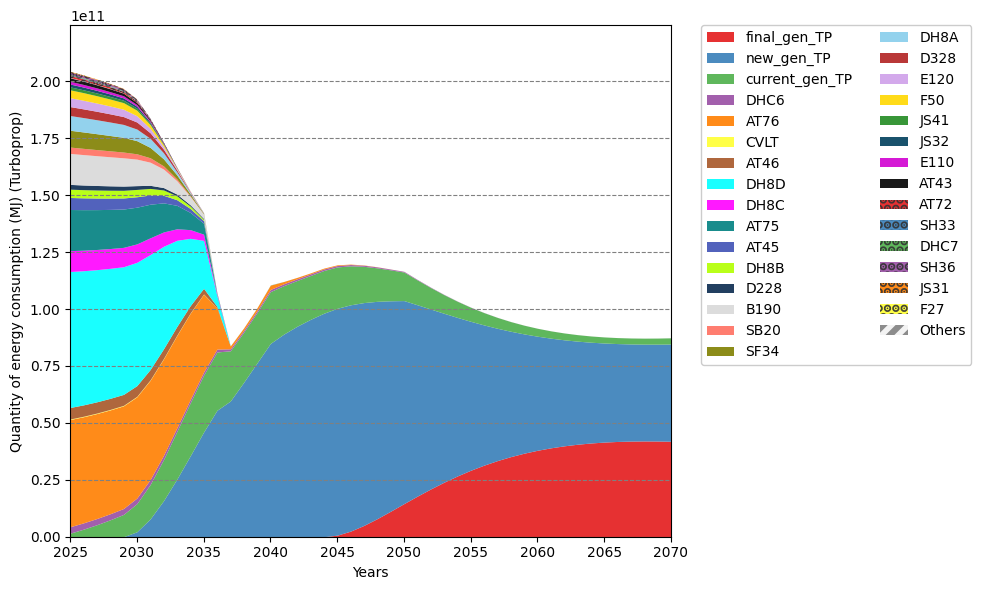

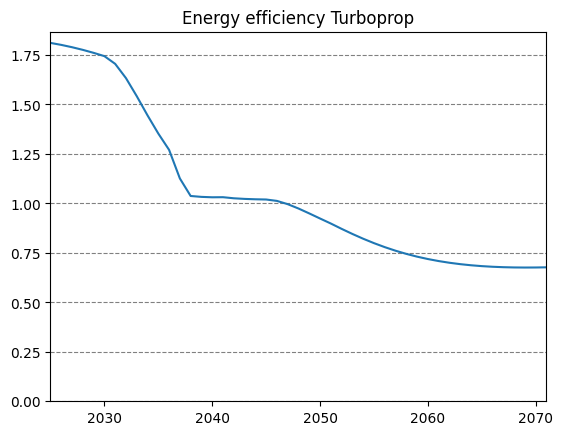

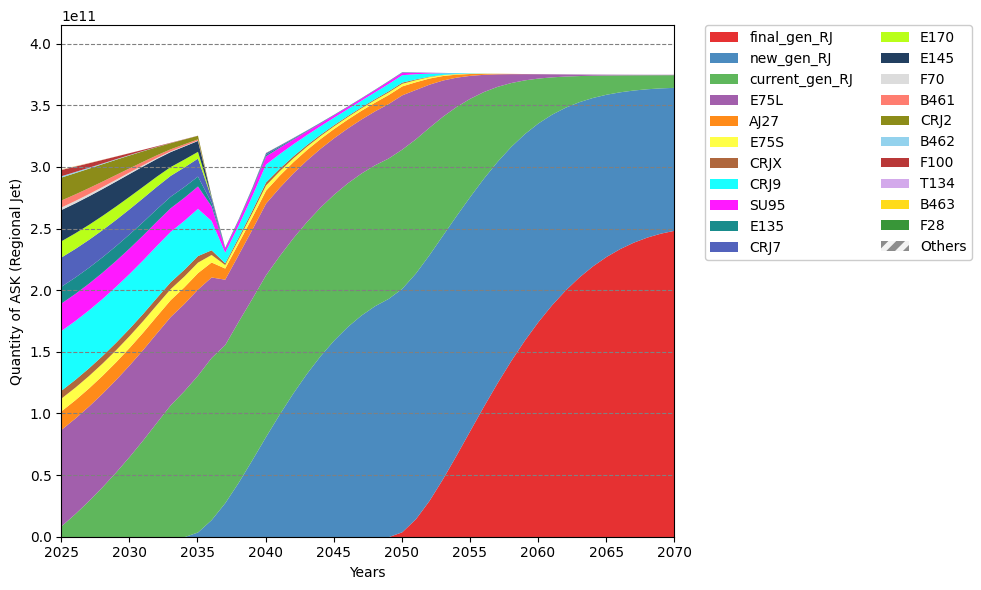

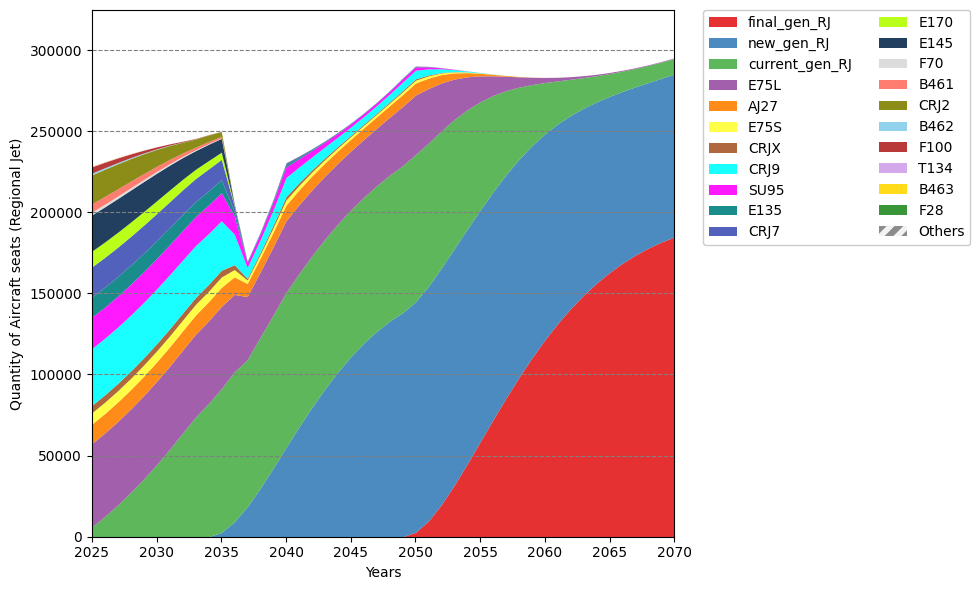

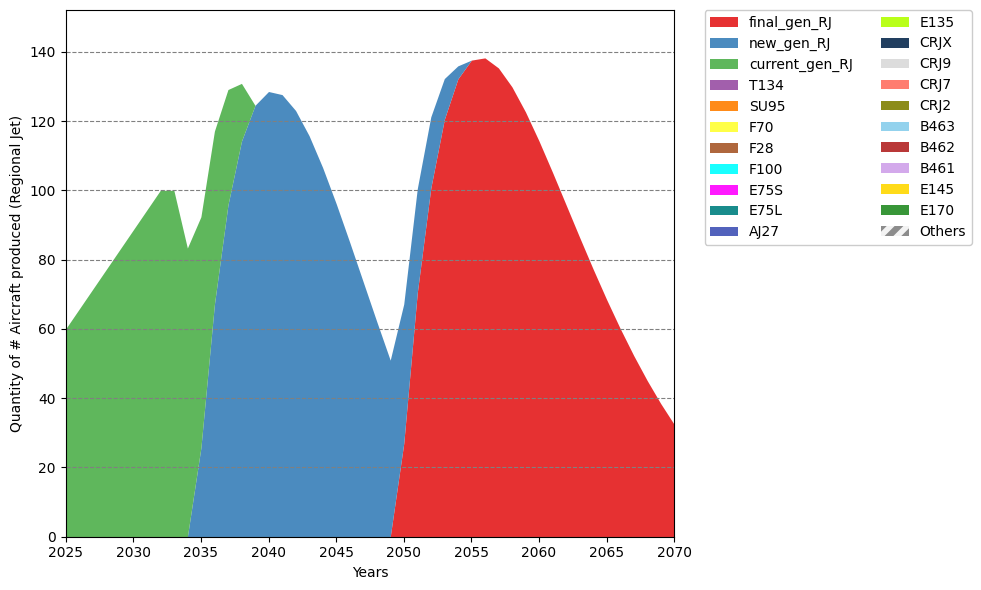

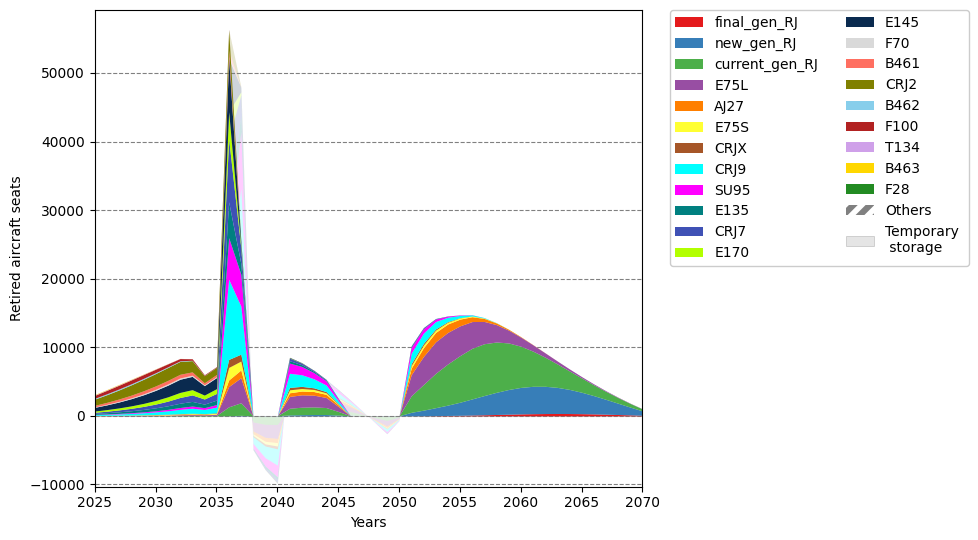

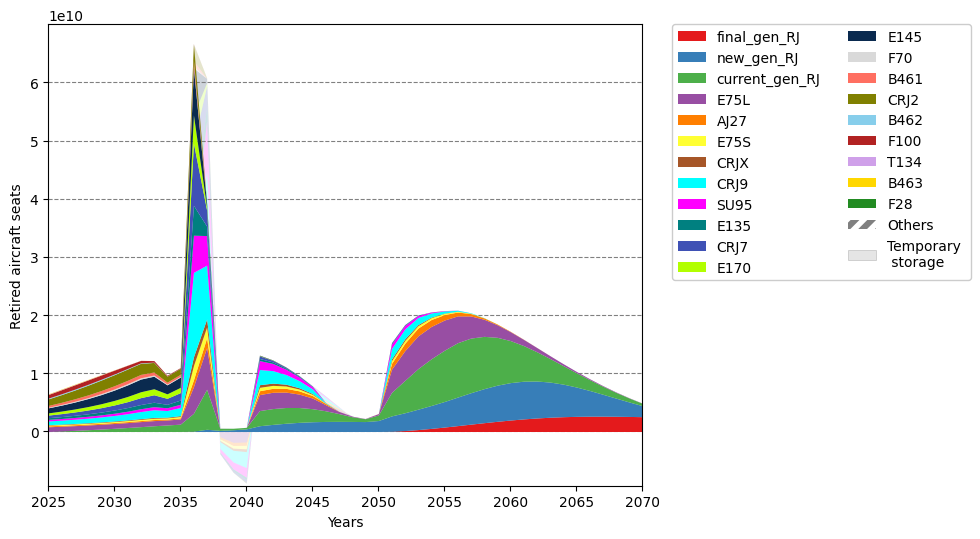

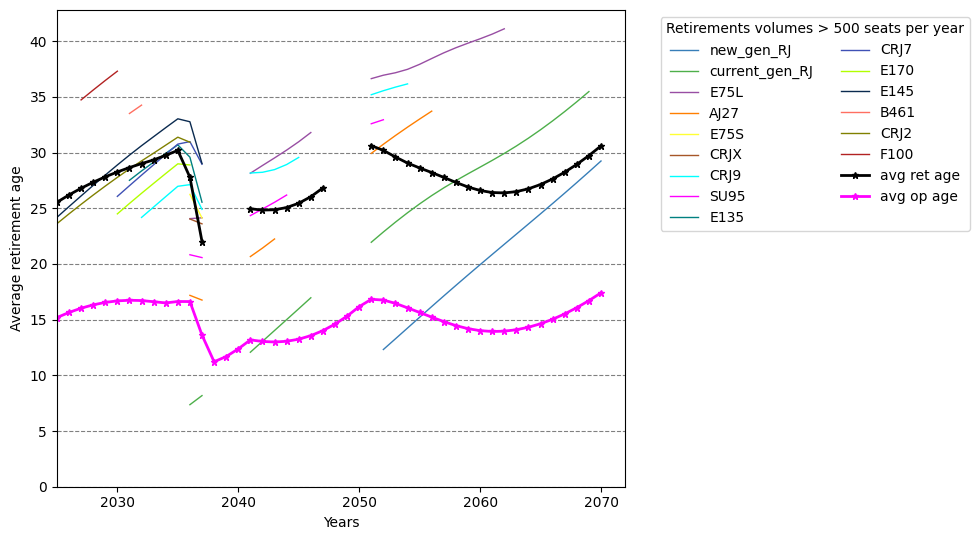

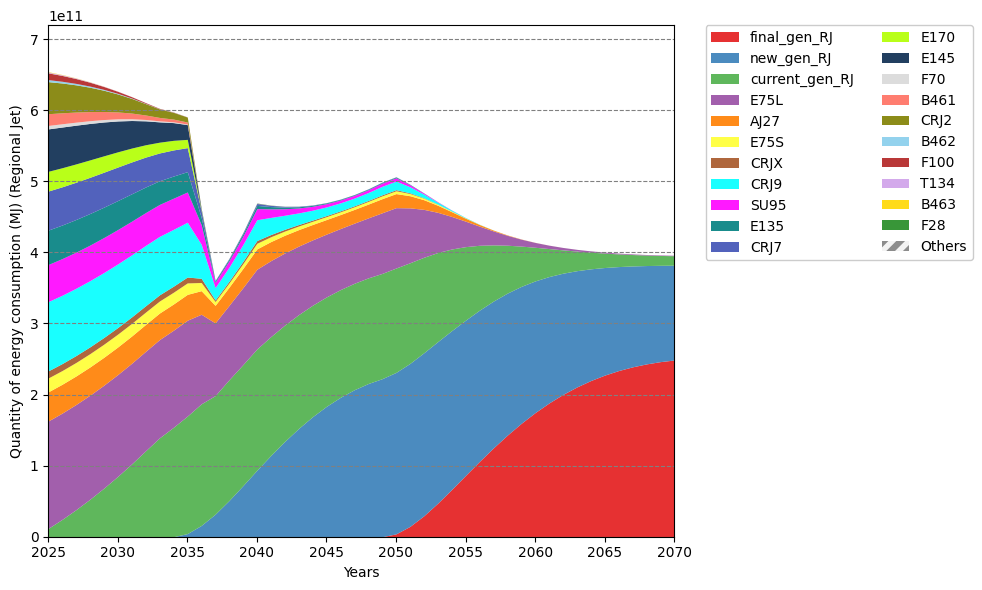

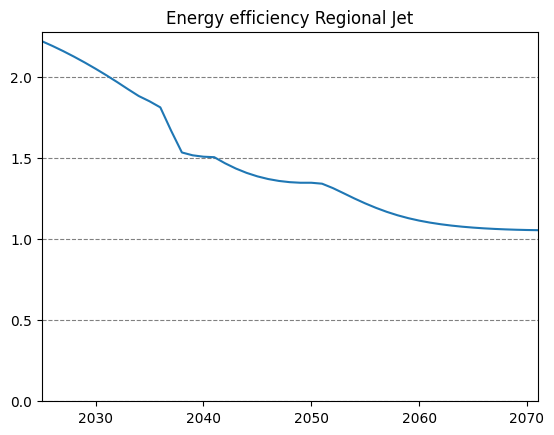

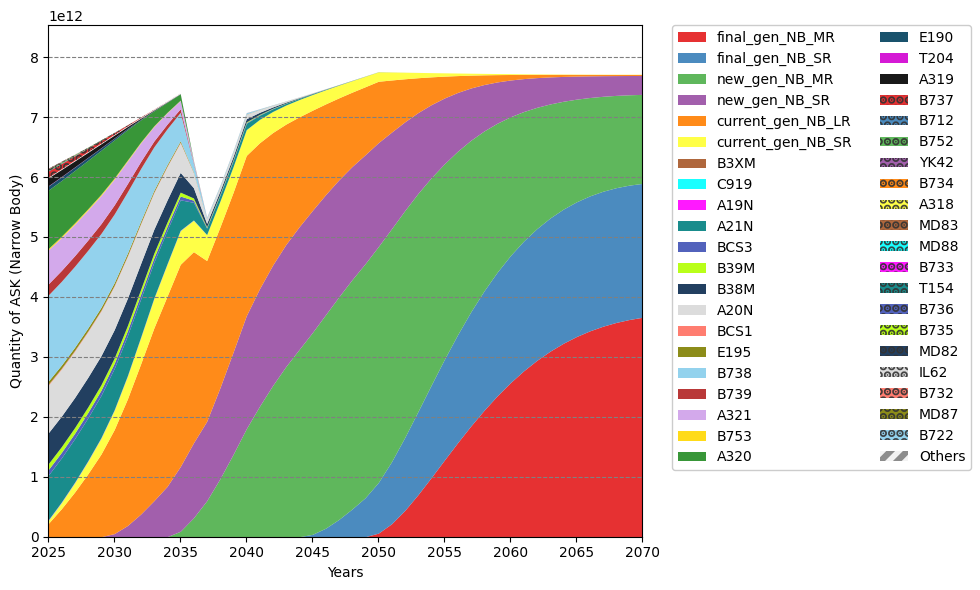

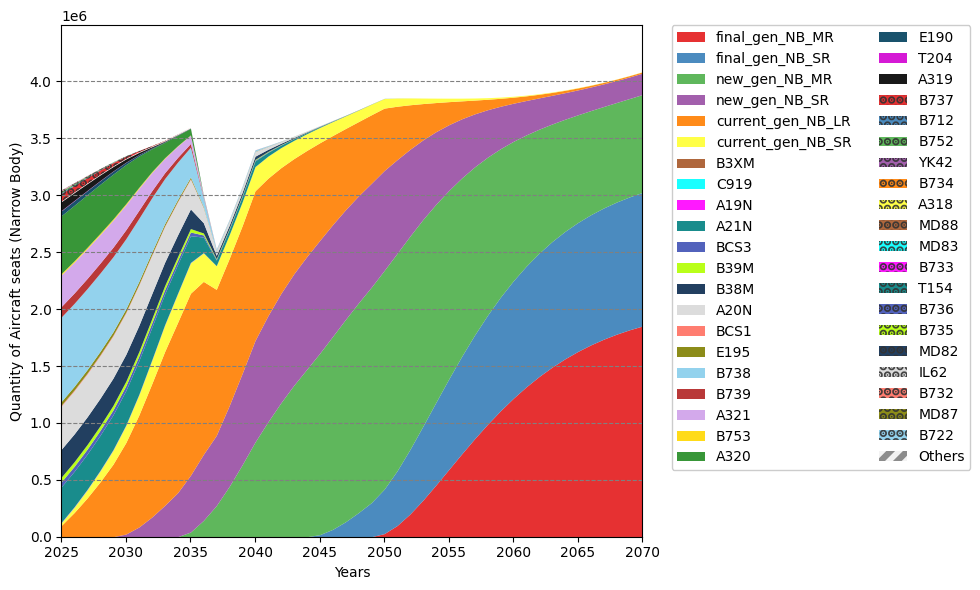

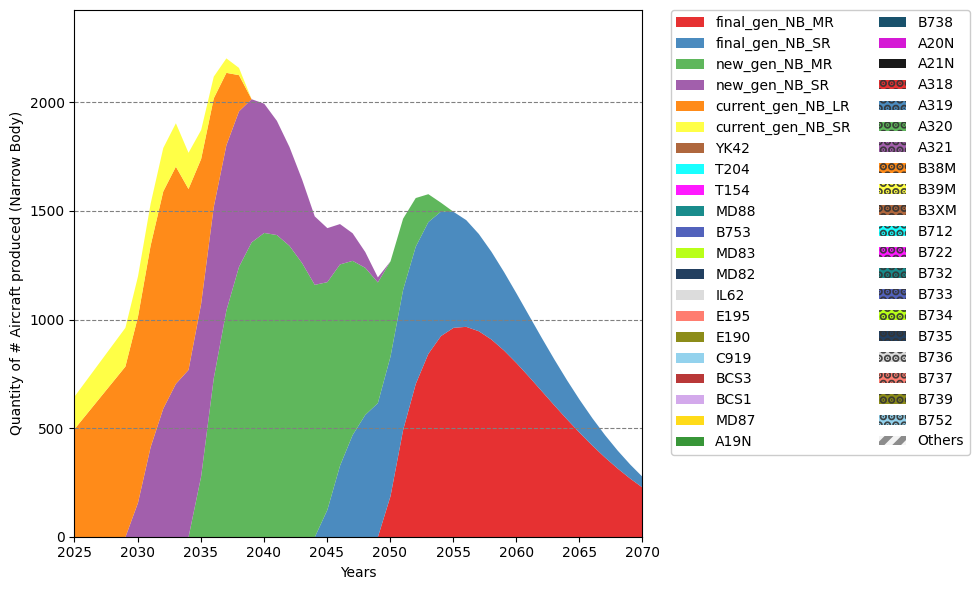

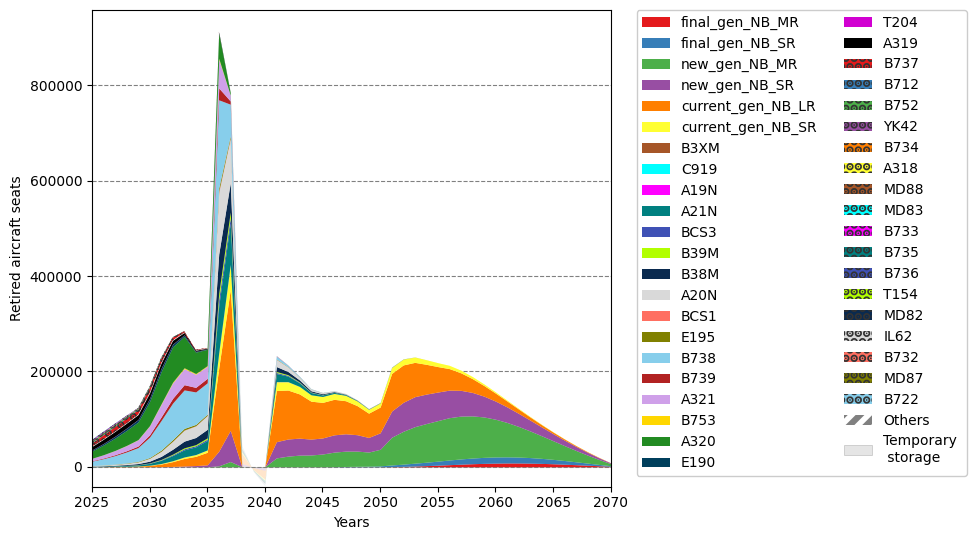

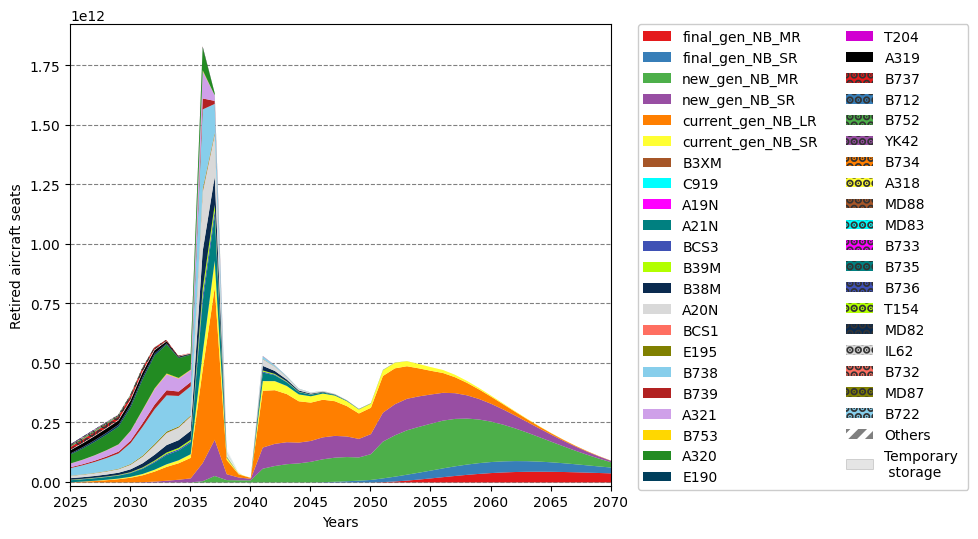

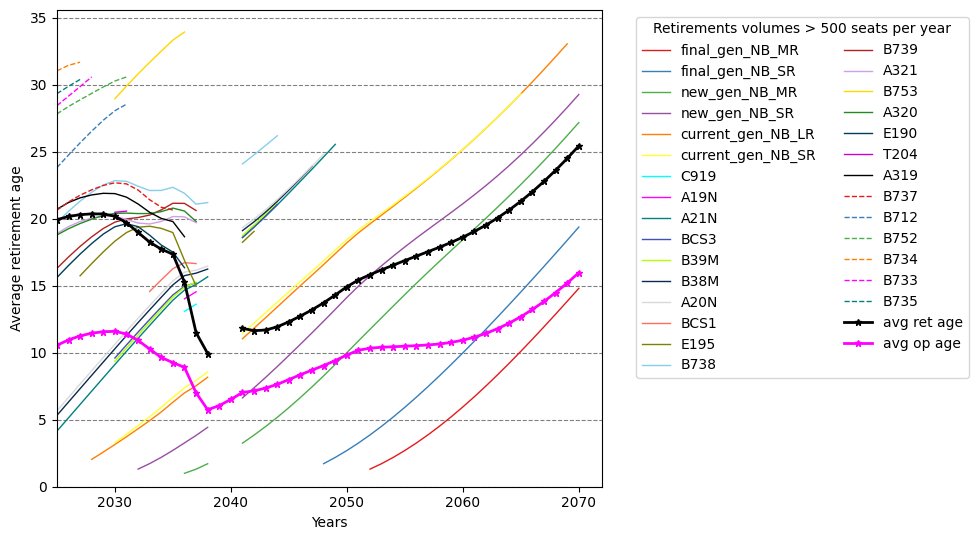

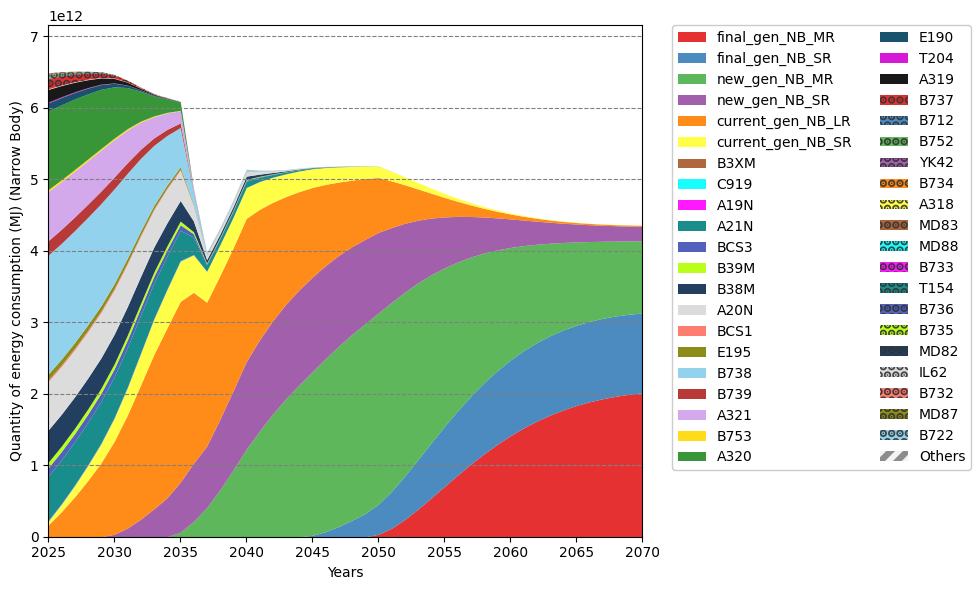

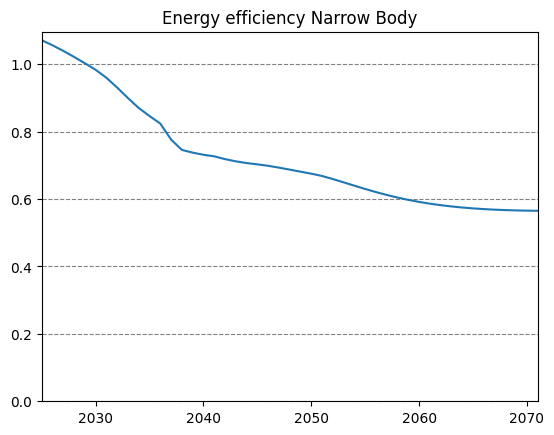

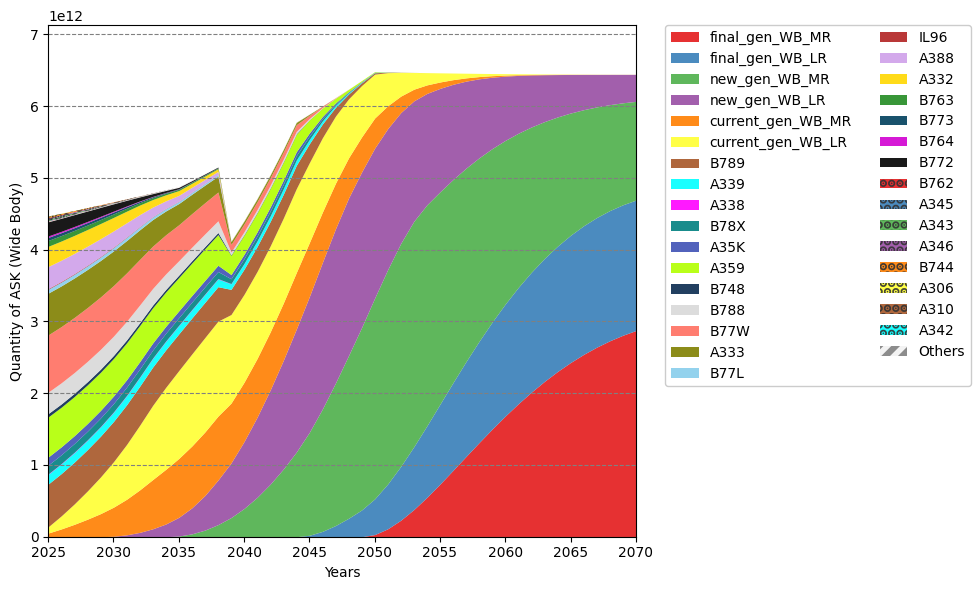

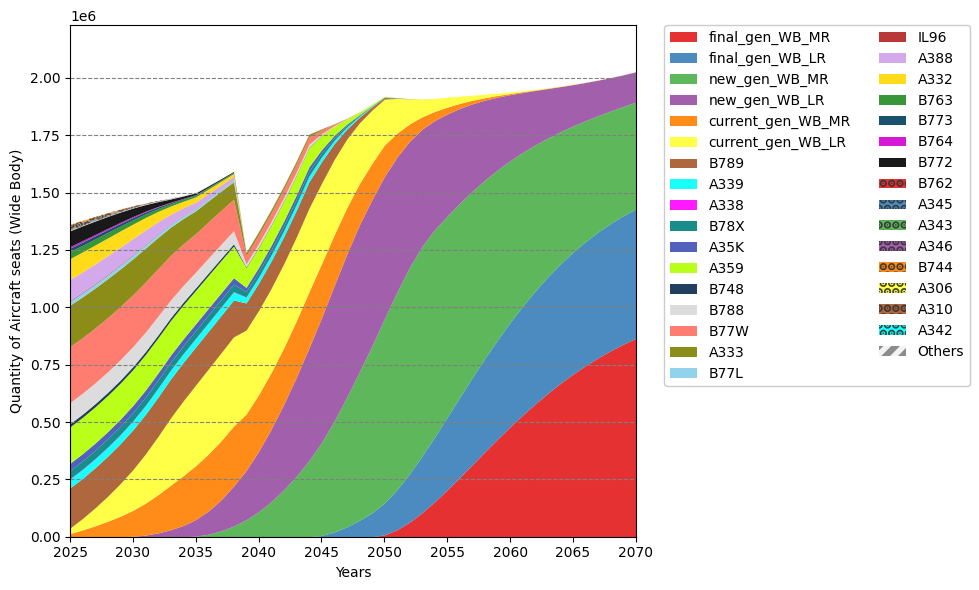

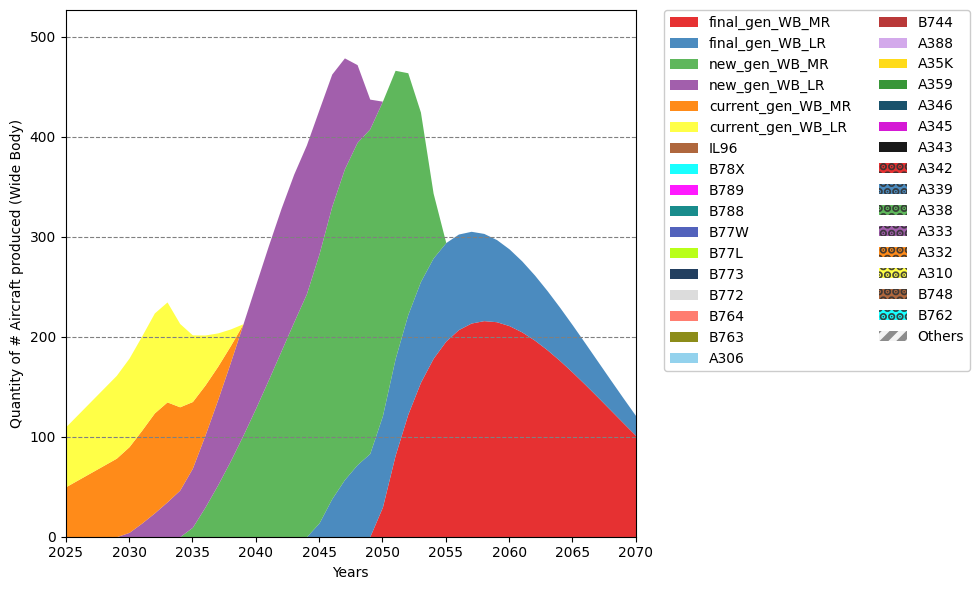

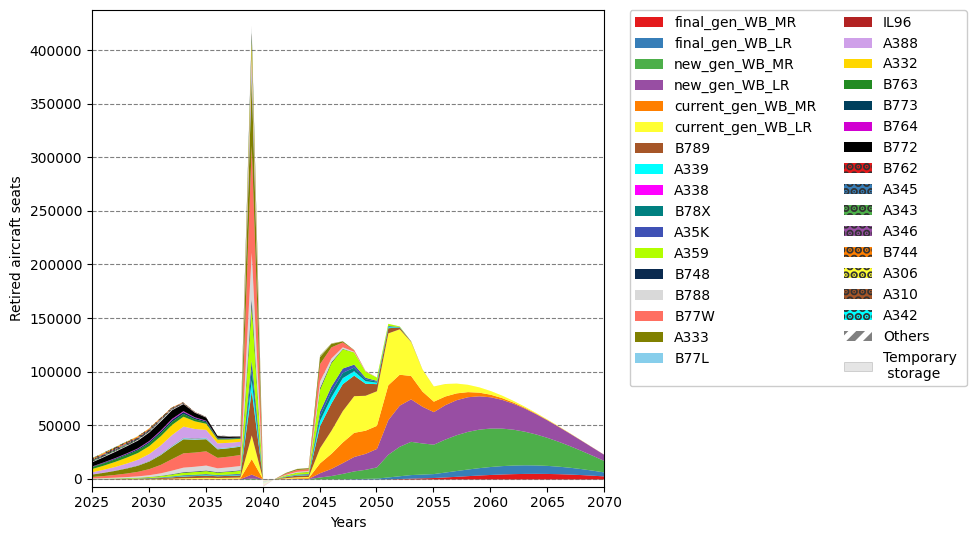

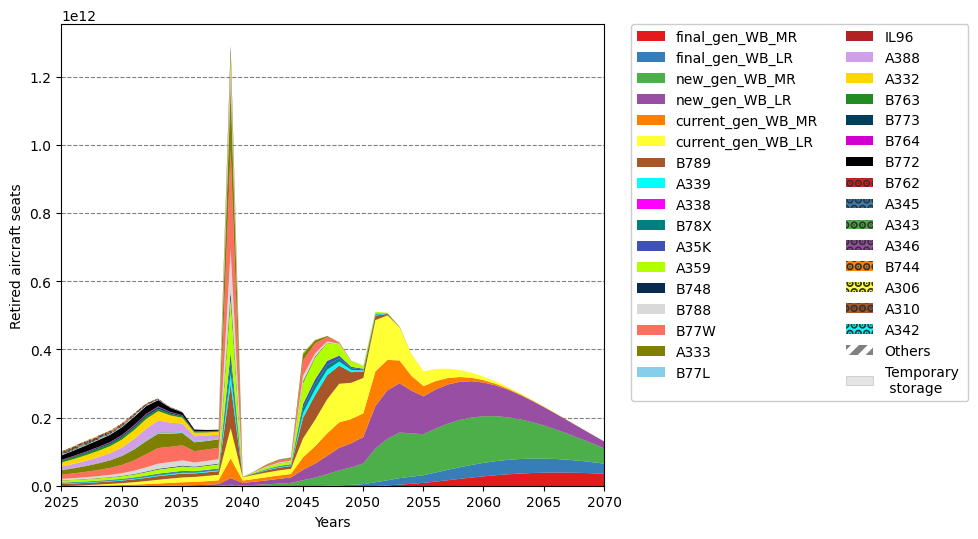

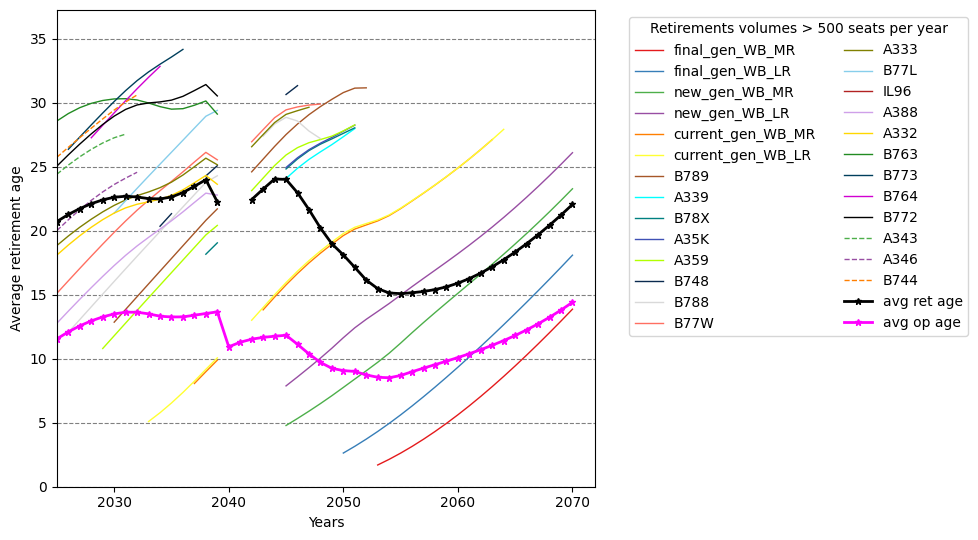

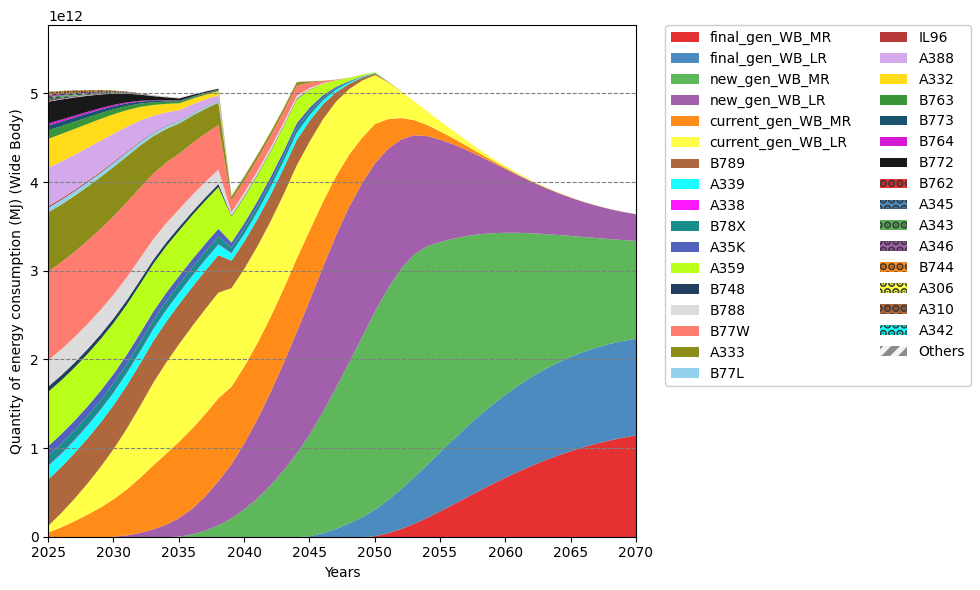

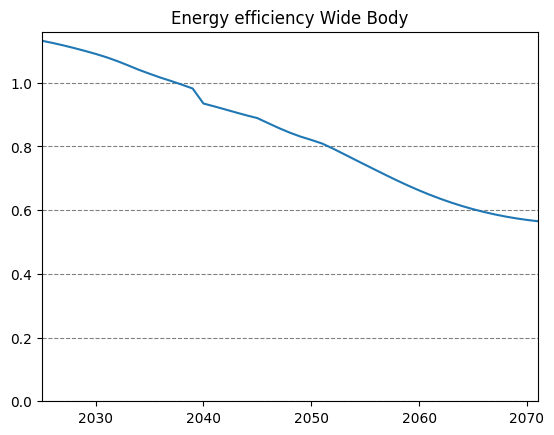

In [8]:
# The push model is exposed directly on the process (mirrors `process.fleet_model`).
# Render every push chart per segment:
# fleet / ASK / deliveries / retirements / retirement-age / energy / energy-intensity.
push_model = process.push_fleet_model
push_model.plot()
plt.show()

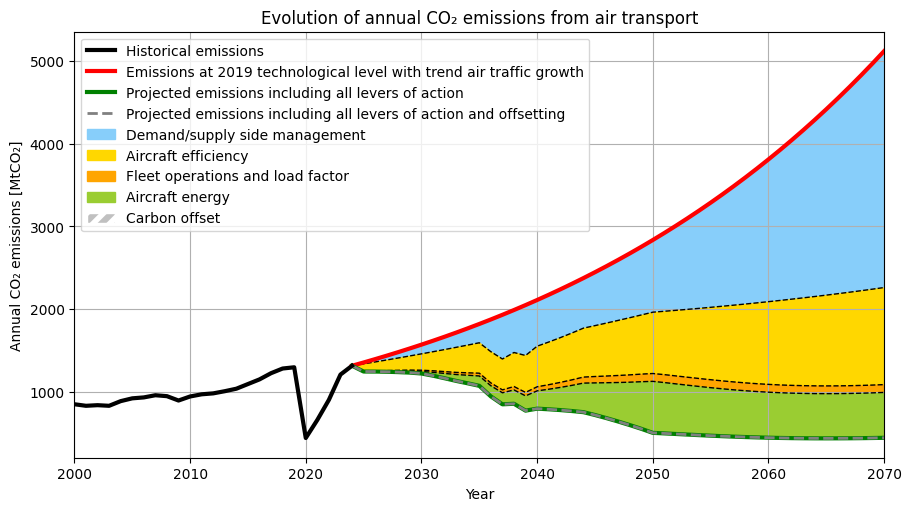

In [6]:
process.plot("air_transport_co2_emissions")

## Guard: the push model requires a 2024 pivot

Selecting `models_efficiency_push` on any other pivot (e.g. the default
`prospection_start_year = 2020`) fails fast at build time, rather than silently
mis-dating the 2024 fleet.

In [7]:
import tempfile
import yaml
from pathlib import Path

# The scenario markets file lives next to this notebook (CWD = notebook dir). The bad
# config is written to a temp dir, so pass markets_push.yaml as an absolute path.
markets_push = str(Path("data/markets_push.yaml").resolve())
bad_cfg = {  # no data.inputs -> prospection_start_year defaults to 2020
    "models": {
        "markets": {"markets_data_file": markets_push},
        "climate": {"climate_model_data_file": "default"},
        "energy": {
            "energy_carriers_model_data_file": "default",
            "resources_model_data_file": "default",
            "processes_model_data_file": "default",
        },
        "standards": [
            "models_traffic",
            "models_efficiency_push",
            "models_energy_without_fuel_effect",
            "models_offset",
            "models_emissions",
            "models_sustainability",
            "models_energy_cost",
            "models_operation_cost_top_down",
        ],
    },
}
with tempfile.NamedTemporaryFile("w", suffix=".yaml", delete=False) as f:
    yaml.safe_dump(bad_cfg, f)
    tmp = f.name

try:
    create_process(configuration_file=tmp)
    print("No error (unexpected).")
except ValueError as e:
    print("Guard fired as expected:\n")
    print(e)

Guard fired as expected:

PassengerAircraftEfficiencyFleetPush requires the scenario to pivot on 2024, i.e. prospection_start_year == 2025 (last_historical_year == 2024). The push engine is calibrated to the end-2024 fleet (agg_fleet_end_2024.xlsx) and the 2024 per-type ASK/MJ. Got prospection_start_year=2020 (last_historical_year=2019). Provide a 2025-pivot scenario whose historic *_init vectors run 2000-2024 (see tutorials/13_change_the_prospection_start_year/data/inputs_2025.json).
